Load the data

In [105]:
import pandas as pd
from pathlib import Path

# Get the current directory
current_dir = Path.cwd()

# Load the CSV files
matches_file_path = current_dir.parent / 'data' / 'epic7_matches.csv'
hero_codes_file_path = current_dir.parent / 'data' / 'hero_code_to_name.csv'

matches_df = pd.read_csv(matches_file_path)

matches_df.head()

,my_team_picks,enemy_team_picks,my_bans,enemy_bans,first_pick_team,winner
0,"[{""hero_code"": ""c2042"", ""pick_order"": 2}, {""he...","[{""hero_code"": ""c2007"", ""pick_order"": 1}, {""he...","[""c2066"", ""c2011""]","[""c2066"", ""c2113""]",enemy_team,my_team
1,"[{""hero_code"": ""c2112"", ""pick_order"": 2}, {""he...","[{""hero_code"": ""c4158"", ""pick_order"": 1}, {""he...","[""c2066"", ""c2011""]","[""c1153"", ""c1117""]",enemy_team,my_team
2,"[{""hero_code"": ""c2042"", ""pick_order"": 2}, {""he...","[{""hero_code"": ""c2090"", ""pick_order"": 1}, {""he...","[""c2066"", ""c2011""]","[""c2066"", ""c5110""]",enemy_team,my_team
3,"[{""hero_code"": ""c2112"", ""pick_order"": 1}, {""he...","[{""hero_code"": ""c2042"", ""pick_order"": 2}, {""he...","[""c2066"", ""c2011""]","[""c1153"", ""c1117""]",my_team,my_team
4,"[{""hero_code"": ""c2042"", ""pick_order"": 1}, {""he...","[{""hero_code"": ""c1153"", ""pick_order"": 2}, {""he...","[""c2066"", ""c2011""]","[""c5110"", ""c2112""]",my_team,enemy_team


Rearrange to winning and losing teams

In [106]:
# Iterate over each match and apply the rules
lst = []
for index, row in matches_df.iterrows():
    winner = row['winner']  # Adjust this if your column name is different
    
    # Map winner to my_team and loser to enemy_team
    first_pick_mapping = {'my_team':'winning_team', 'enemy_team':'losing_team'} if winner == 'my_team' else {'my_team':'losing_team', 'enemy_team':'winning_team'}
    mapping = {'winning_team':'my', 'losing_team':'enemy'} if winner == 'my_team' else {'winning_team':'enemy', 'losing_team':'my'}

    new_row = {
        'winning_team_picks': row[mapping['winning_team'] + '_team_picks'],
        'losing_team_picks': row[mapping['losing_team'] + '_team_picks'],
        'winning_team_bans': row[mapping['winning_team'] + '_bans'],
        'losing_team_bans': row[mapping['losing_team'] + '_bans'],
        'first_pick_team': first_pick_mapping[row['first_pick_team']] 
    }

    # Append the new row
    lst.append(new_row)

    
# Initialize a new DataFrame to store the rearranged data
rearranged_matches_df = pd.DataFrame(lst, columns=[
    'winning_team_picks',
    'losing_team_picks',
    'winning_team_bans',
    'losing_team_bans',
    'first_pick_team'
])

# Shuffle the matches
rearranged_matches_df = rearranged_matches_df.sample(frac=1).reset_index(drop=True)

# # Save the new DataFrame to a CSV file
# rearranged_matches_df.to_csv('data/rearranged_epic7_matches.csv', index=False)
# print('Rearranged data has been saved to data/rearranged_epic7_matches.csv')

rearranged_matches_df.head()

,winning_team_picks,losing_team_picks,winning_team_bans,losing_team_bans,first_pick_team
0,"[{""hero_code"": ""c2112"", ""pick_order"": 2}, {""he...","[{""hero_code"": ""c2066"", ""pick_order"": 1}, {""he...","[""c1117"", ""c1153""]","[""c1153"", ""c2113""]",losing_team
1,"[{""hero_code"": ""c2090"", ""pick_order"": 2}, {""he...","[{""hero_code"": ""c2016"", ""pick_order"": 1}, {""he...","[""c1153"", ""c2112""]","[""c1153"", ""c1133""]",losing_team
2,"[{""hero_code"": ""c2090"", ""pick_order"": 1}, {""he...","[{""hero_code"": ""c2113"", ""pick_order"": 2}, {""he...","[""c1153"", ""c2066""]","[""c1163"", ""c2011""]",winning_team
3,"[{""hero_code"": ""c5110"", ""pick_order"": 1}, {""he...","[{""hero_code"": ""c2113"", ""pick_order"": 2}, {""he...","[""c2066"", ""c2090""]","[""c2066"", ""c2090""]",winning_team
4,"[{""hero_code"": ""c2066"", ""pick_order"": 1}, {""he...","[{""hero_code"": ""c1151"", ""pick_order"": 2}, {""he...","[""c2112"", ""c2042""]","[""c2095"", ""c1153""]",winning_team


convert the matches to snapshots and one hot encode

In [107]:
import numpy as np
import ast
import pandas as pd

# Load the hero codes mapping
hero_mapping_df = pd.read_csv(hero_codes_file_path, header=None, names=['code', 'name'])
hero_codes = hero_mapping_df['code'].tolist()

# Define the vocabulary
vocab = ['Null', 'Ban', 'Pick', 'winning_team', 'losing_team', 'c_null'] + hero_codes + [str(i) for i in range(11)]
vocab_size = len(vocab)

# Create a mapping from word to index for one-hot encoding
word_to_index = {word: idx for idx, word in enumerate(vocab)}
index_to_word = {idx: word for word, idx in word_to_index.items()}

# Function to convert JSON-like strings into lists of dictionaries
def parse_json_like_string(json_str):
    try:
        return ast.literal_eval(json_str)
    except ValueError:
        return []

# Function to create snapshots for predicting the hero code
def create_pick_snapshots(match):
    snapshots = []
    targets = []
    sequence = []

    # Parse the JSON-like strings
    winning_picks = parse_json_like_string(match['winning_team_picks'])
    losing_picks = parse_json_like_string(match['losing_team_picks'])
    winning_bans = parse_json_like_string(match['winning_team_bans'])
    losing_bans = parse_json_like_string(match['losing_team_bans'])

    # Add all prebans to the sequence
    for ban in winning_bans:
        sequence.extend(['Ban', '0', 'winning_team', ban if ban else 'c_null'])
    for ban in losing_bans:
        sequence.extend(['Ban', '0', 'losing_team', ban if ban else 'c_null'])

    # Combine and sort all picks
    all_picks = winning_picks + losing_picks
    all_picks_sorted = sorted(all_picks, key=lambda x: x['pick_order'])

    # Create snapshots and targets for picks 1 to 10
    for pick in all_picks_sorted:
        pick_order = int(pick['pick_order'])
        team = 'winning_team' if pick in winning_picks else 'losing_team'

        if 1 <= pick_order <= 10:
            # Create a snapshot before the current pick
            snapshot = sequence + ['Pick', str(pick_order), team]

            # Pad the snapshot to 56 words
            snapshot = snapshot[:56] + ['Null'] * max(0, 56 - len(snapshot))
            snapshots.append(snapshot)

            # Set the target to be only the hero code (4th word)
            targets.append(pick['hero_code'])

        # Add the current pick to the sequence
        sequence.extend(['Pick', str(pick_order), team, pick['hero_code']])

    return snapshots, targets

# Convert all matches into snapshots and targets
results = rearranged_matches_df.apply(create_pick_snapshots, axis=1)

# Flatten the list of snapshots and targets
snapshots = []
targets = []

for match_snapshots, match_targets in results:
    snapshots.extend(match_snapshots)
    targets.extend(match_targets)

# Convert snapshots to NumPy array for efficient one-hot encoding
snapshots = np.array(snapshots)

# Use NumPy for efficient one-hot encoding of snapshots
def one_hot_encode_snapshots(snapshots, vocab_size, word_to_index):
    encoded = np.zeros((len(snapshots), 56, vocab_size), dtype=np.int32)
    for i, snapshot in enumerate(snapshots):
        indices = [word_to_index.get(word, word_to_index['Null']) for word in snapshot]
        encoded[i, np.arange(56), indices] = 1
    return encoded

# Efficient one-hot encoding for targets
def one_hot_encode_targets(targets, vocab_size, word_to_index):
    indices = [word_to_index.get(target, word_to_index['Null']) for target in targets]
    encoded = np.zeros((len(targets), vocab_size), dtype=np.int32)
    encoded[np.arange(len(targets)), indices] = 1
    return encoded

# One-hot encode snapshots and targets
one_hot_encoded_snapshots = one_hot_encode_snapshots(snapshots, vocab_size, word_to_index)
one_hot_encoded_targets = one_hot_encode_targets(targets, vocab_size, word_to_index)

# Output the shape of the encoded data for verification
print(f'One-hot encoded snapshots shape: {one_hot_encoded_snapshots.shape}')
print(f'One-hot encoded targets shape: {one_hot_encoded_targets.shape}')


One-hot encoded snapshots shape: (9930, 56, 356)
One-hot encoded targets shape: (9930, 356)


Visualise the input and target data

In [108]:
# Function to decode one-hot encoded sequences back to words
def decode_one_hot_sequence(one_hot_encoded, index_to_word):
    return [index_to_word[np.argmax(token)] for token in one_hot_encoded]

# Format the decoded sequence into lines with 4 words each, excluding 'Null'
def format_decoded_sequence(decoded_sequence):
    
    # Remove 'Null' padding for easier reading
    filtered_sequence = [word for word in decoded_sequence if word != 'Null']
    lines = [' '.join(filtered_sequence[i:i+4]) for i in range(0, len(filtered_sequence), 4)]
    return '\n'.join(lines)

# print(decode_one_hot_sequence(one_hot_encoded_snapshots[0], index_to_word))

# Compare snapshots and targets with improved formatting
def compare_snapshots_and_targets(snapshots, targets, index_to_word, num_samples=5):
    for i in range(min(num_samples, len(snapshots))):
        # Decode the current snapshot
        decoded_snapshot = decode_one_hot_sequence(snapshots[i], index_to_word)
        
        # Decode the target (hero code)
        target_index = np.argmax(targets[i])  # Get the index of the predicted hero code
        decoded_target = index_to_word.get(target_index, 'Null')

        # Remove 'Null' padding and format the snapshot
        formatted_snapshot = format_decoded_sequence(decoded_snapshot)

        # Display the comparison with improved formatting
        print(f"Snapshot {i+1}:")
        print(formatted_snapshot)
        print("\nPredicted Hero Code:")
        print(decoded_target)
        print("=" * 50)

# Assuming 'one_hot_encoded_snapshots' and 'one_hot_encoded_targets' are available from earlier steps
# Call the comparison function to check the first 20 samples
compare_snapshots_and_targets(one_hot_encoded_snapshots, one_hot_encoded_targets, index_to_word, num_samples=20)


Snapshot 1:
Ban 0 winning_team c1117
Ban 0 winning_team c1153
Ban 0 losing_team c1153
Ban 0 losing_team c2113
Pick 1 losing_team

Predicted Hero Code:
c2066
Snapshot 2:
Ban 0 winning_team c1117
Ban 0 winning_team c1153
Ban 0 losing_team c1153
Ban 0 losing_team c2113
Pick 1 losing_team c2066
Pick 2 winning_team

Predicted Hero Code:
c2112
Snapshot 3:
Ban 0 winning_team c1117
Ban 0 winning_team c1153
Ban 0 losing_team c1153
Ban 0 losing_team c2113
Pick 1 losing_team c2066
Pick 2 winning_team c2112
Pick 3 winning_team

Predicted Hero Code:
c1133
Snapshot 4:
Ban 0 winning_team c1117
Ban 0 winning_team c1153
Ban 0 losing_team c1153
Ban 0 losing_team c2113
Pick 1 losing_team c2066
Pick 2 winning_team c2112
Pick 3 winning_team c1133
Pick 4 losing_team

Predicted Hero Code:
c2106
Snapshot 5:
Ban 0 winning_team c1117
Ban 0 winning_team c1153
Ban 0 losing_team c1153
Ban 0 losing_team c2113
Pick 1 losing_team c2066
Pick 2 winning_team c2112
Pick 3 winning_team c1133
Pick 4 losing_team c2106
Pick 

In [109]:
# Calculate the sizes for training, validation, and test splits
num_samples = len(one_hot_encoded_snapshots)
train_size = int(0.7 * num_samples)
val_size = int(0.15 * num_samples)

# Split the data into training, validation, and test sets using slicing
X_train = one_hot_encoded_snapshots[:train_size]
y_train = one_hot_encoded_targets[:train_size]

X_val = one_hot_encoded_snapshots[train_size:train_size + val_size]
y_val = one_hot_encoded_targets[train_size:train_size + val_size]

X_test = one_hot_encoded_snapshots[train_size + val_size:]
y_test = one_hot_encoded_targets[train_size + val_size:]

# Output the shapes of the split data
print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Validation set shape: {X_val.shape}, {y_val.shape}")
print(f"Test set shape: {X_test.shape}, {y_test.shape}")

Training set shape: (6951, 56, 356), (6951, 356)
Validation set shape: (1489, 56, 356), (1489, 356)
Test set shape: (1490, 56, 356), (1490, 356)


In [117]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization

# Define the LSTM model
model = Sequential()

# LSTM layer to process the 56-word input sequence
model.add(LSTM(128, input_shape=(56, 356), return_sequences=True))
model.add(LSTM(128, input_shape=(56, 356), return_sequences=False))
model.add(Dropout(0.3))
model.add(BatchNormalization())

# Dense layer to predict the hero code (single word)
model.add(Dense(vocab_size, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_26 (LSTM)                  │ (None, 56, 128)        │       248,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_27 (LSTM)                  │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 356)            │        45,924 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 426,340 (1.63 MB)

 Trainable params: 426,084 (1.63 MB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 166ms/step - accuracy: 0.0478 - loss: 5.5628 - val_accuracy: 0.0866 - val_loss: 5.3341
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 154ms/step - accuracy: 0.0973 - loss: 4.6967 - val_accuracy: 0.0873 - val_loss: 5.0281
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 154ms/step - accuracy: 0.0938 - loss: 4.5088 - val_accuracy: 0.0994 - val_loss: 4.8309
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 155ms/step - accuracy: 0.0941 - loss: 4.2992 - val_accuracy: 0.0853 - val_loss: 4.6701
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 154ms/step - accuracy: 0.0925 - loss: 4.2248 - val_accuracy: 0.0772 - val_loss: 4.6439
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 151ms/step - accuracy: 0.0944 - loss: 4.1002 - val_accuracy: 0.0887 - val_loss: 4.3912
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 154ms/step - accuracy: 0.1116 - loss: 3.9743 - val_accuracy: 0.0557 - val_loss: 4.2496
Epoch 8/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 155ms/step - accuracy: 0.1103 - loss: 3.9039 - val_accuracy: 0.

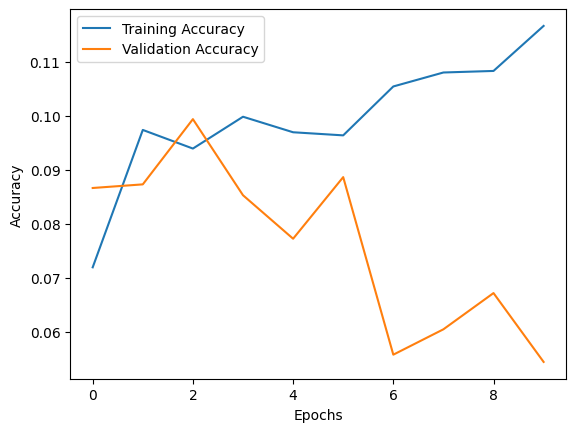

In [118]:
# Train the model
history = model.fit(
    X_train, y_train, 
    validation_data=(X_val, y_val), 
    epochs=10, batch_size=256
)

# Plot the training and validation accuracy
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [119]:
import numpy as np

# Make predictions on the test data
y_pred = model.predict(X_test)

# Function to decode one-hot encoded hero code back to words
def decode_hero_code(one_hot_vector, index_to_word):
    hero_code_index = np.argmax(one_hot_vector)  # Find the index of the predicted word
    return index_to_word.get(hero_code_index, 'Unknown')

# Visualise predictions and actual targets for a few examples
def visualise_single_word_predictions(X_test, y_test, y_pred, index_to_word, num_samples=5):
    for i in range(min(num_samples, len(X_test))):
        
        # Decode the input snapshot
        decoded_input = decode_one_hot_sequence(X_test[i], index_to_word)
        formatted_input = ' '.join([word for word in decoded_input if word != 'Null'])

        # Decode the actual target (hero code)
        actual_hero = decode_hero_code(y_test[i], index_to_word)

        # Decode the predicted target (hero code)
        predicted_hero = decode_hero_code(y_pred[i], index_to_word)

        # Display the input, actual target, and predicted target
        print(f"Example {i+1}:")
        print(f"Input Snapshot:\n{formatted_input}")
        print(f"Actual Hero Code: {actual_hero}")
        print(f"Predicted Hero Code: {predicted_hero}")
        print("=" * 50)

# Call the function to visualise the predictions on the test set
visualise_single_word_predictions(X_test, y_test, y_pred, index_to_word, num_samples=5)

each draft 15 choices
14 choices
each choice 4 word
total 56 words
vocab size 356 


47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
Example 1:
Input Snapshot:
Ban 0 winning_team c1153 Ban 0 winning_team c2066 Ban 0 losing_team c1153 Ban 0 losing_team c1117 Pick 1 losing_team
Actual Hero Code: c5110
Predicted Hero Code: c5110
Example 2:
Input Snapshot:
Ban 0 winning_team c1153 Ban 0 winning_team c2066 Ban 0 losing_team c1153 Ban 0 losing_team c1117 Pick 1 losing_team c5110 Pick 2 winning_team
Actual Hero Code: c2042
Predicted Hero Code: c5110
Example 3:
Input Snapshot:
Ban 0 winning_team c1153 Ban 0 winning_team c2066 Ban 0 losing_team c1153 Ban 0 losing_team c1117 Pick 1 losing_team c5110 Pick 2 winning_team c2042 Pick 3 winning_team
Actual Hero Code: c2090
Predicted Hero Code: c2016
Example 4:
Input Snapshot:
Ban 0 winning_team c1153 Ban 0 winning_team c2066 Ban 0 losing_team c1153 Ban 0 losing_team c1117 Pick 1 losing_team c5110 Pick 2 winning_team c2042 Pick 3 winning_team c2090 Pick 4 losing_team
Actual Hero Code: c2011
Predicted Hero Code: c2016
Example 5:
Input Snapshot